In [1]:
# First cell
import os, sys
os.chdir("/kaggle/working")
!git clone https://github.com/DevasishY/uncertainty-hateful-memes.git
PROJECT_ROOT = "/kaggle/working/uncertainty-hateful-memes"
sys.path.insert(0, PROJECT_ROOT)


Cloning into 'uncertainty-hateful-memes'...
remote: Enumerating objects: 12, done.
remote: Counting objects: 100% (12/12), done.
remote: Compressing objects: 100% (10/10), done.
remote: Total 12 (delta 0), reused 12 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (12/12), 276.08 KiB | 2.00 MiB/s, done.


In [21]:
from src.data.load_hateful_memes import load_hateful_memes
from PIL import Image

train_df = load_hateful_memes("train")
dev_df = load_hateful_memes("dev")
test_df = load_hateful_memes("test")
train_df.head()

Reading: /kaggle/input/hateful-memes-dataset/data/train.jsonl exists: True
Reading: /kaggle/input/hateful-memes-dataset/data/dev.jsonl exists: True
Reading: /kaggle/input/hateful-memes-dataset/data/test.jsonl exists: True


,id,img,label,text,img_path
0,42953,img/42953.png,0,its their character not their color that matters,/kaggle/input/hateful-memes-dataset/data/img/4...
1,23058,img/23058.png,0,don't be afraid to love again everyone is not ...,/kaggle/input/hateful-memes-dataset/data/img/2...
2,13894,img/13894.png,0,putting bows on your pet,/kaggle/input/hateful-memes-dataset/data/img/1...
3,37408,img/37408.png,0,i love everything and everybody! except for sq...,/kaggle/input/hateful-memes-dataset/data/img/3...
4,82403,img/82403.png,0,"everybody loves chocolate chip cookies, even h...",/kaggle/input/hateful-memes-dataset/data/img/8...


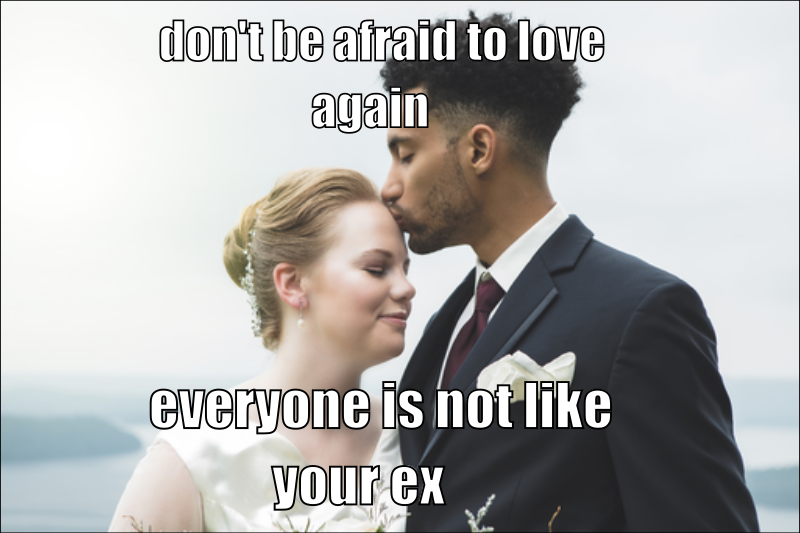

In [27]:
img = Image.open(train_df.iloc[1]["img_path"]).convert("RGB")
display(img)

In [30]:
#  zeroshot using cacheing for efficient computation
import torch
from torch.utils.data import DataLoader
from transformers import CLIPModel, CLIPProcessor
from PIL import Image
from tqdm import tqdm 

# 1. setup
device = "cuda" if torch.cuda.is_available() else "cpu"
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")


# ---------------------------------------------------------
# STEP 1: PRE-COMPUTE THE "CLASSIFIER" (The Cache)
# ---------------------------------------------------------
# Define your "Classes"
labels = ["positive", "negative"]

# Process text ONCE
text_inputs = processor(text=labels, return_tensors="pt", padding=True).to(device)

with torch.no_grad():
    # Get the embedding vectors (Shape: [2, 512])
    text_features = model.get_text_features(**text_inputs)
    
    # NORMALIZE (Cosine similarity requires unit vectors)
    text_features = text_features / text_features.norm(p=2, dim=-1, keepdim=True)


# ---------------------------------------------------------
# STEP 2: LOOP THROUGH IMAGES (The Inference)
# ---------------------------------------------------------
predictions = []
probabilities = []
batch_size = 32  # Process 32 images at a time for speed

# We iterate through the dataframe in chunks
for i in tqdm(range(0, len(train_df), batch_size)):
    
    # A. Load a batch of images
    batch_rows = train_df.iloc[i : i + batch_size]
    batch_images = [Image.open(path).convert("RGB") for path in batch_rows["img_path"]]
    
    # B. Process images (Prepare pixels)
    image_inputs = processor(images=batch_images, return_tensors="pt", padding=True).to(device)
    
    with torch.no_grad():
        # C. Run ONLY the Image Encoder
        image_features = model.get_image_features(**image_inputs)
        image_features = image_features / image_features.norm(p=2, dim=-1, keepdim=True)
        
        # D. Calculate Similarity (Matrix Multiplication)
        # [Batch_Size, 512] @ [512, 2] -> [Batch_Size, 2]
        similarity_scores = image_features @ text_features.T
        
        # Scale scores (CLIP specific scaling factor)
        logit_scale = model.logit_scale.exp()
        logits = similarity_scores * logit_scale
        
        # E. Get Probabilities and Predictions
        probs = logits.softmax(dim=1)
        preds = torch.argmax(probs, dim=1)
        
        # Save results (Move to CPU to save GPU memory)
        probabilities.extend(probs.cpu().numpy())
        predictions.extend(preds.cpu().numpy())

100%|██████████| 266/266 [02:50<00:00,  1.56it/s]


--- Zero-Shot Performance Metrics ---
Accuracy: 0.5567

Classification Report:
              precision    recall  f1-score   support

 Non-Hateful       0.67      0.62      0.64      5450
     Hateful       0.40      0.45      0.42      3050

    accuracy                           0.56      8500
   macro avg       0.53      0.53      0.53      8500
weighted avg       0.57      0.56      0.56      8500



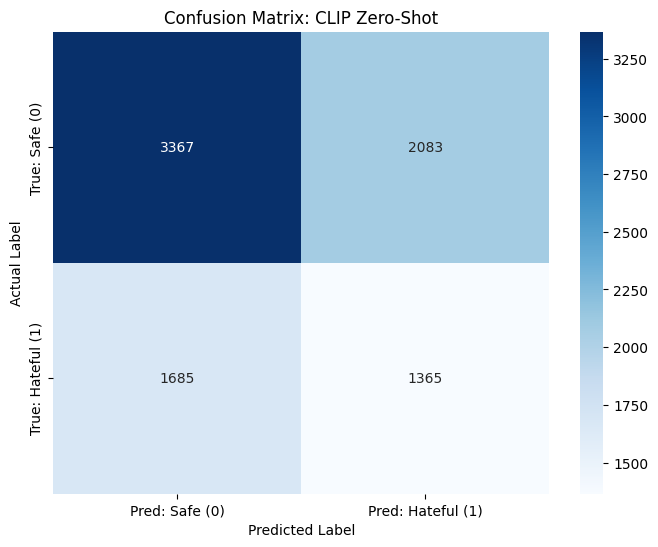

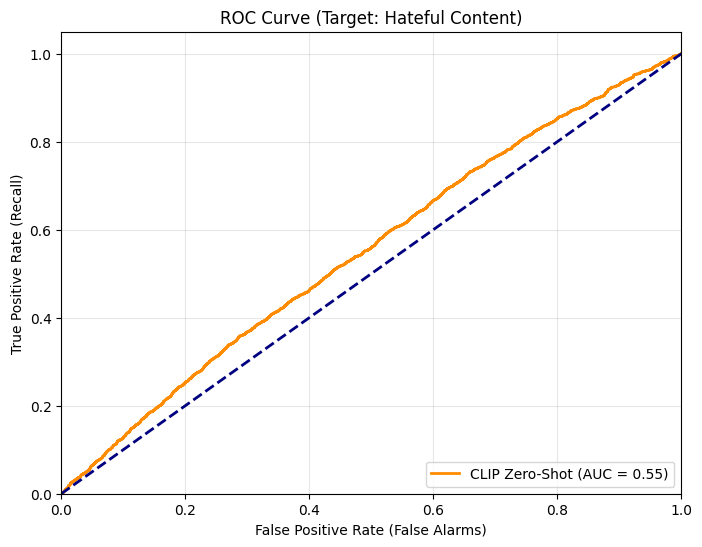

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc, classification_report

# ---------------------------------------------------------
# 1. SETUP & VERIFICATION 
# ---------------------------------------------------------
# In train_df, 0 = Non-Hateful, 1 = Hateful
# In CLIP, labels = ["a non-hateful meme", "a hateful meme"]
# Result: CLIP Index 0 matches Label 0. CLIP Index 1 matches Label 1.

y_true = train_df["label"].values 
y_pred = np.array(predictions) # Contains 0s and 1s

# Get Probability of the POSITIVE Class (Hateful = Class 1)
# Since "Hateful" is at index 1 in our list, we take column 1
y_scores = np.array(probabilities)[:, 1] 

# ---------------------------------------------------------
# 2. PRINT METRICS (Order matters here!)
# ---------------------------------------------------------
print("--- Zero-Shot Performance Metrics ---")
print(f"Accuracy: {accuracy_score(y_true, y_pred):.4f}")

# Target Names must match the integer order (0, then 1)
# 0 -> Non-Hateful
# 1 -> Hateful
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["Non-Hateful", "Hateful"]))

# ---------------------------------------------------------
# 3. CONFUSION MATRIX (Order: 0=Top/Left, 1=Bottom/Right)
# ---------------------------------------------------------
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
# Labels must follow the 0, 1 order
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=["Pred: Safe (0)", "Pred: Hateful (1)"],
            yticklabels=["True: Safe (0)", "True: Hateful (1)"])
plt.title('Confusion Matrix: CLIP Zero-Shot')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

# ---------------------------------------------------------
# 4. ROC CURVE (Focus on Class 1)
# ---------------------------------------------------------
# We want to detect Class 1 (Hateful), so pos_label=1
fpr, tpr, thresholds = roc_curve(y_true, y_scores, pos_label=1) 
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'CLIP Zero-Shot (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (False Alarms)')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve (Target: Hateful Content)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()


/tmp/ipykernel_55/4227143655.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x='True Label', y='CLIP Score', palette="Set2")


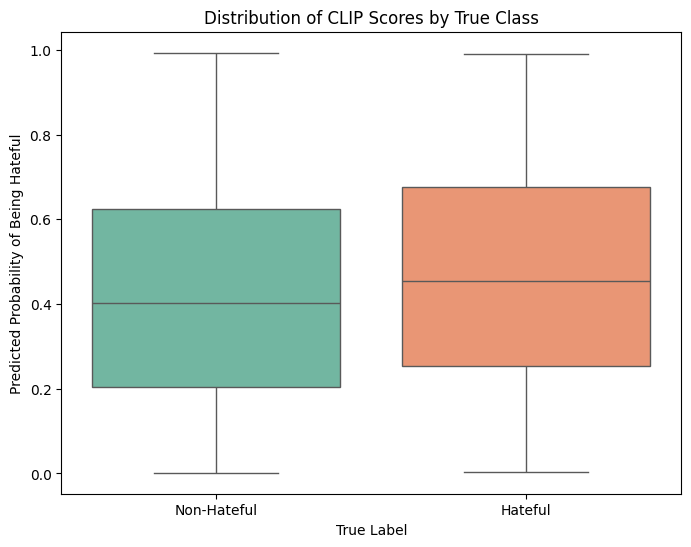

In [35]:
import seaborn as sns
import pandas as pd

# Create a small dataframe for plotting
plot_df = pd.DataFrame({
    'True Label': ['Hateful' if x==1 else 'Non-Hateful' for x in y_true],
    'CLIP Score': y_scores
})

plt.figure(figsize=(8, 6))
sns.boxplot(data=plot_df, x='True Label', y='CLIP Score', palette="Set2")
plt.title("Distribution of CLIP Scores by True Class")
plt.ylabel("Predicted Probability of Being Hateful")
plt.show()


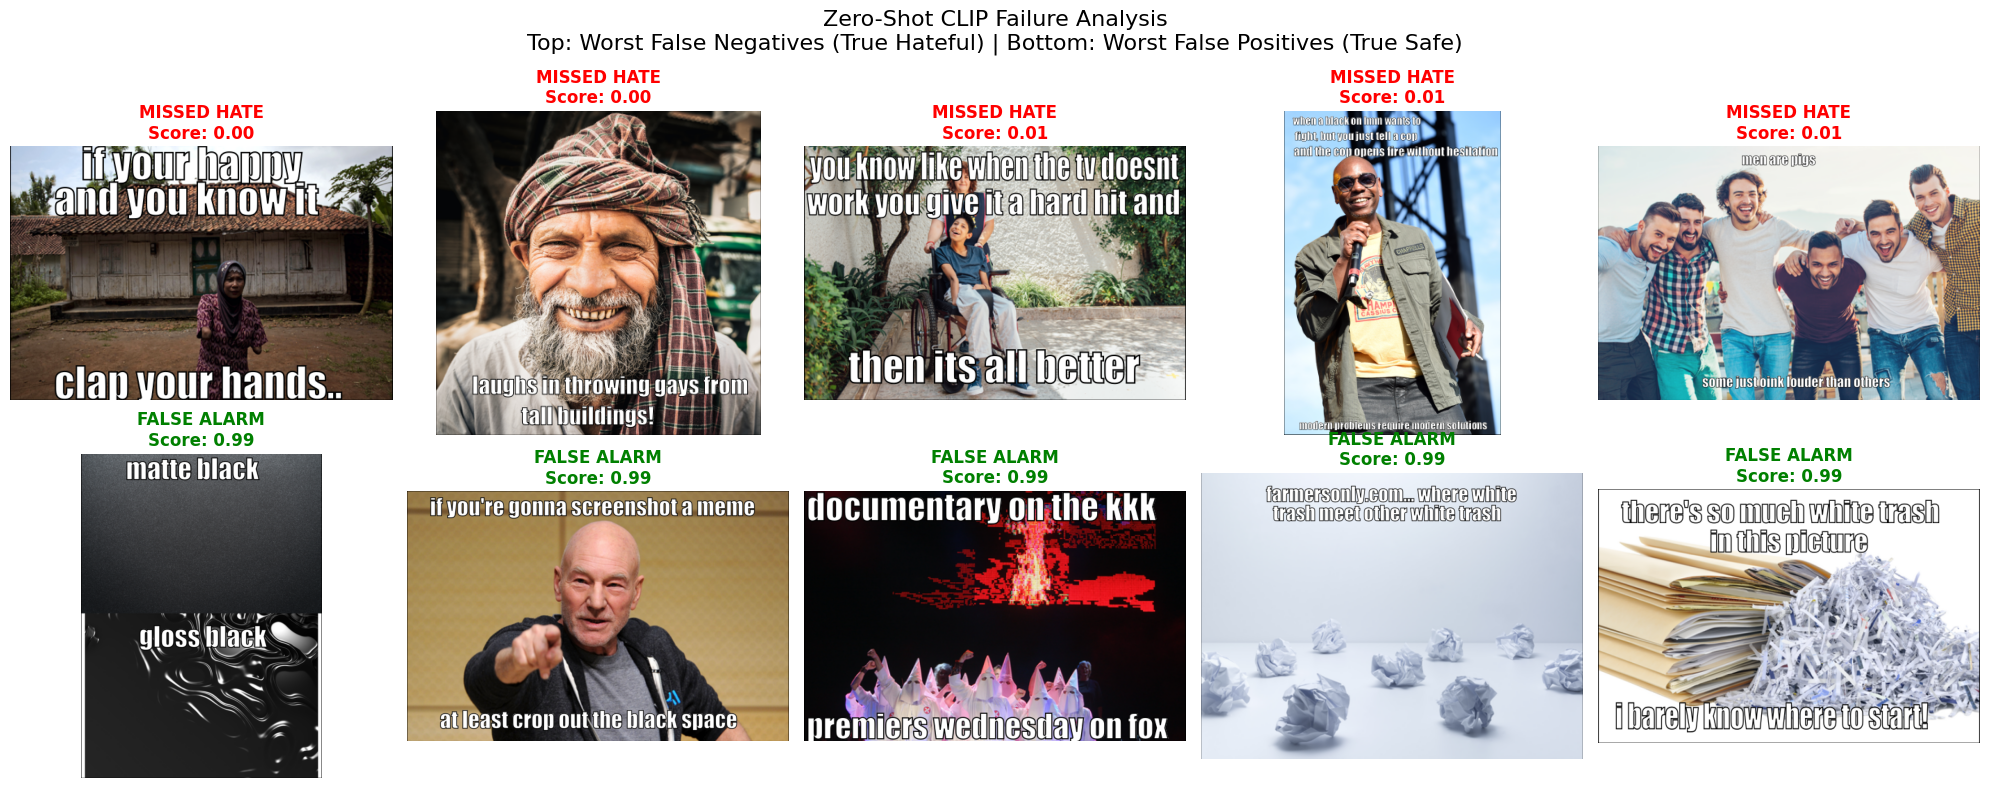

In [36]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

# ------------------------------------------------------------------
# 1. FIND INDICES
# ------------------------------------------------------------------

# A. False Negatives (Missed Hate)
# Logic: True Label is 1 (Hateful), but Score is LOW (model thought it was safe)
hateful_indices = np.where(y_true == 1)[0]
# Sort by score ascending (lowest scores first)
sorted_hateful_indices = hateful_indices[np.argsort(y_scores[hateful_indices])]
# Take top 5 lowest
fn_indices = sorted_hateful_indices[:5]

# B. False Positives (False Alarms)
# Logic: True Label is 0 (Safe), but Score is HIGH (model thought it was hateful)
safe_indices = np.where(y_true == 0)[0]
# Sort by score ascending (highest scores will be at the end)
sorted_safe_indices = safe_indices[np.argsort(y_scores[safe_indices])]
# Take top 5 highest (last 5)
fp_indices = sorted_safe_indices[-5:]


# ------------------------------------------------------------------
# 2. PLOT THE GRID
# ------------------------------------------------------------------
fig, axes = plt.subplots(2, 5, figsize=(20, 8))

# ROW 1: False Negatives (Red titles)
for i, idx in enumerate(fn_indices):
    ax = axes[0, i]
    path = train_df.iloc[idx]["img_path"]
    score = y_scores[idx]
    
    try:
        img = Image.open(path).convert("RGB")
        ax.imshow(img)
    except Exception as e:
        ax.text(0.5, 0.5, "Image Not Found", ha='center')
        
    ax.axis('off')
    ax.set_title(f"MISSED HATE\nScore: {score:.2f}", color='red', fontweight='bold')

# ROW 2: False Positives (Green titles)
for i, idx in enumerate(fp_indices):
    ax = axes[1, i]
    path = train_df.iloc[idx]["img_path"]
    score = y_scores[idx]
    
    try:
        img = Image.open(path).convert("RGB")
        ax.imshow(img)
    except Exception as e:
        ax.text(0.5, 0.5, "Image Not Found", ha='center')
        
    ax.axis('off')
    ax.set_title(f"FALSE ALARM\nScore: {score:.2f}", color='green', fontweight='bold')

plt.suptitle("Zero-Shot CLIP Failure Analysis\nTop: Worst False Negatives (True Hateful) | Bottom: Worst False Positives (True Safe)", fontsize=16)
plt.tight_layout()
plt.show()


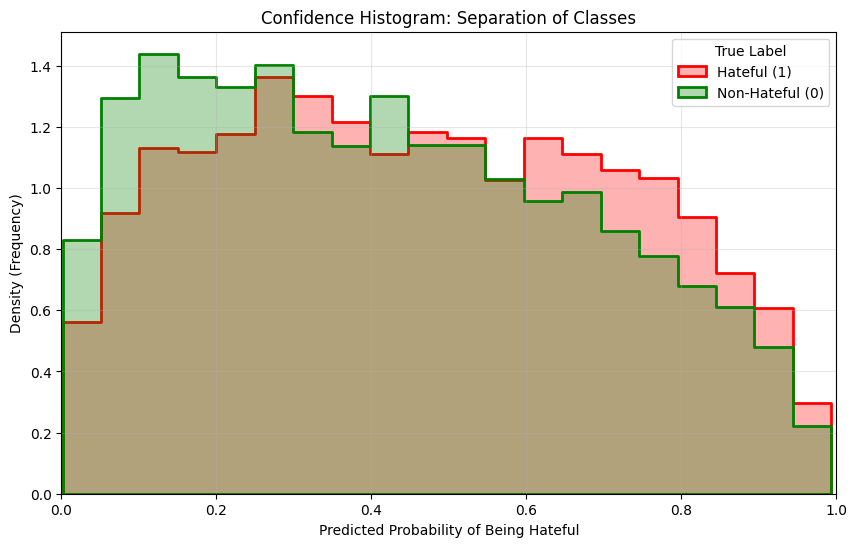

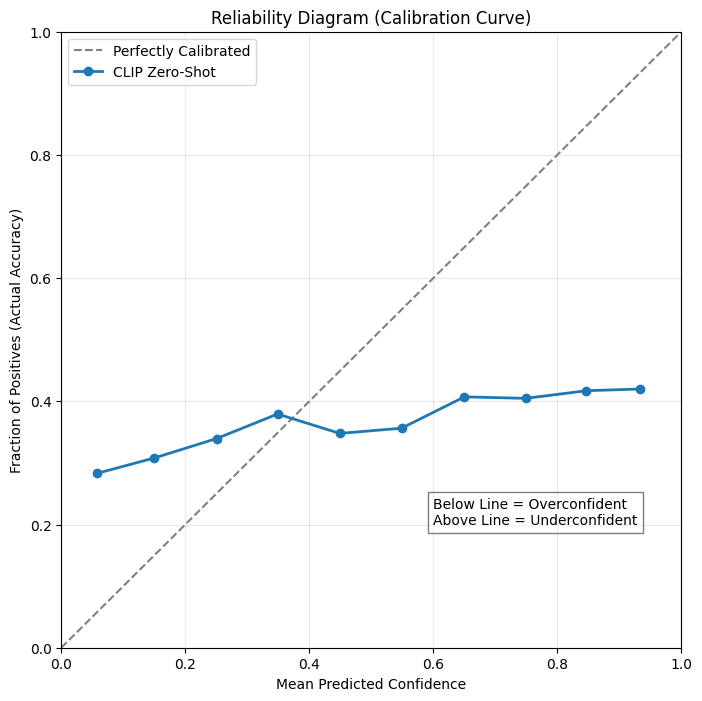

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.calibration import calibration_curve

# ---------------------------------------------------------
# SETUP DATA
# ---------------------------------------------------------
# y_true: Array of 0s (Non-Hateful) and 1s (Hateful)
# y_scores: Array of probabilities for the Hateful class (0.0 to 1.0)
# Make sure these are numpy arrays
y_true = np.array(train_df["label"].values)
y_scores = np.array(probabilities)[:, 1] # Probability of Class 1

# ---------------------------------------------------------
# PLOT 1: CONFIDENCE HISTOGRAM
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))

# We plot two histograms on top of each other
sns.histplot(
    x=y_scores, 
    hue=y_true,          # Colors by True Label
    bins=20,             # 20 bins = 0.05 width each
    stat="density",      # Normalize so total area = 1 (fair comparison)
    common_norm=False,   # Normalize each class independently
    element="step",      # Draw as outlines/steps for clarity
    palette={0: "green", 1: "red"},
    alpha=0.3,           # Transparency fill
    linewidth=2
)

plt.title("Confidence Histogram: Separation of Classes")
plt.xlabel("Predicted Probability of Being Hateful")
plt.ylabel("Density (Frequency)")
plt.legend(title="True Label", labels=["Hateful (1)", "Non-Hateful (0)"])
plt.xlim(0, 1)
plt.grid(alpha=0.3)
plt.show()


# ---------------------------------------------------------
# PLOT 2: CALIBRATION CURVE (Reliability Diagram)
# ---------------------------------------------------------
plt.figure(figsize=(8, 8))

# Calculate the calibration points
# n_bins=10 means we group predictions into buckets: 0-0.1, 0.1-0.2, ...
prob_true, prob_pred = calibration_curve(y_true, y_scores, n_bins=10, strategy='uniform')

# Plot the ideal line (Perfectly Calibrated)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectly Calibrated')

# Plot the model's performance
plt.plot(prob_pred, prob_true, marker='o', linewidth=2, label='CLIP Zero-Shot')

plt.title("Reliability Diagram (Calibration Curve)")
plt.xlabel("Mean Predicted Confidence")
plt.ylabel("Fraction of Positives (Actual Accuracy)")
plt.legend(loc="upper left")
plt.grid(alpha=0.3)
plt.xlim(0, 1)
plt.ylim(0, 1)

# Add interpretation text
plt.text(0.6, 0.2, "Below Line = Overconfident\nAbove Line = Underconfident", 
         bbox=dict(facecolor='white', alpha=0.5))

plt.show()
